In [1]:
# Removes stray light by convolving with a kernel and subtracting

In [1]:
import numpy as np
from astropy.visualization import ZScaleInterval
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.signal import convolve2d



In [2]:
# Synthetic detector readout: simple PSF + Poisson + readout noise

rng = np.random.default_rng(42)

# Detector geometry
ny, nx = 513, 513  # needs to be odd
dit = 1.3  # s

# PSF: 2D Gaussian at frame center
y0, x0 = (ny - 1) / 2.0, (nx - 1) / 2.0
fwhm_pix = 4.0
sigma_pix = fwhm_pix / (2.0 * np.sqrt(2.0 * np.log(2.0)))
yy, xx = np.indices((ny, nx))
psf = np.exp(-0.5 * ((xx - x0) ** 2 + (yy - y0) ** 2) / sigma_pix ** 2)
psf /= psf.sum()

peak_flux_e = 5.0e4  # electrons in central pixel before noise (order-of-magnitude test level)
signal_e = psf * peak_flux_e / psf.max()

# Background + dark current (electrons)
sky_e = 100.0
dark_current_e_per_s = 0.05
background_e = sky_e + dark_current_e_per_s * dit

# Photon noise (Poisson in electron units)
expected_e = signal_e + background_e
noisy_e = rng.poisson(expected_e).astype(np.float64)

# Readout noise
readout_noise_e = 15.0
noisy_e += rng.normal(0.0, readout_noise_e, size=(ny, nx))

# ADU conversion
gain_e_per_adu = 2.5
readout_adu = noisy_e / gain_e_per_adu

print(f"Frame shape: {readout_adu.shape}")
print(f"PSF peak (noise-free): {signal_e.max():.1f} e-")
print(f"Readout min/median/max [ADU]: {readout_adu.min():.2f} / {np.median(readout_adu):.2f} / {readout_adu.max():.2f}")



Frame shape: (513, 513)
PSF peak (noise-free): 50000.0 e-
Readout min/median/max [ADU]: 3.35 / 40.01 / 19938.46


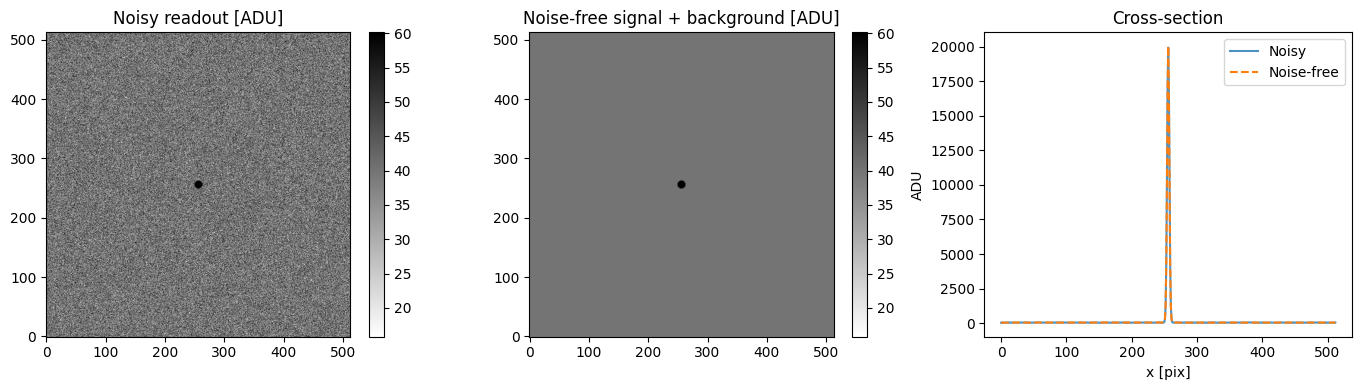

In [4]:
z = ZScaleInterval()
vmin, vmax = z.get_limits(readout_adu)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

im0 = axs[0].imshow(readout_adu, origin="lower", cmap="gray_r", vmin=vmin, vmax=vmax)
axs[0].set_title("Noisy readout [ADU]")
fig.colorbar(im0, ax=axs[0], fraction=0.046)

# Noise-free reference for comparison
noise_free_adu = expected_e / gain_e_per_adu
im1 = axs[1].imshow(noise_free_adu, origin="lower", cmap="gray_r", vmin=vmin, vmax=vmax)
axs[1].set_title("Noise-free signal + background [ADU]")
fig.colorbar(im1, ax=axs[1], fraction=0.046)

# Central cross-section
row = ny // 2
axs[2].plot(readout_adu[row, :], label="Noisy", alpha=0.8)
axs[2].plot(noise_free_adu[row, :], label="Noise-free", linestyle="--")
axs[2].set_xlabel("x [pix]")
axs[2].set_ylabel("ADU")
axs[2].set_title("Cross-section")
axs[2].legend()

plt.tight_layout()
plt.show()


In [5]:
# Centered 4-pointed cruciform (+): same (ny, nx) as readout, sharp arms in ADU
def cruciform_shape(ny, nx, y0, x0):
    arm_half_length = 90.0  # pix — extent of each arm from center
    arm_half_width = 4.0    # pix — half-thickness of each arm
    star_level_adu = 25.0

    horizontal_arm = (np.abs(yy - y0) <= arm_half_width) & (np.abs(xx - x0) <= arm_half_length)
    vertical_arm = (np.abs(xx - x0) <= arm_half_width) & (np.abs(yy - y0) <= arm_half_length)

    cruciform = np.zeros((ny, nx), dtype=np.float64)
    cruciform[horizontal_arm | vertical_arm] = star_level_adu

    return cruciform

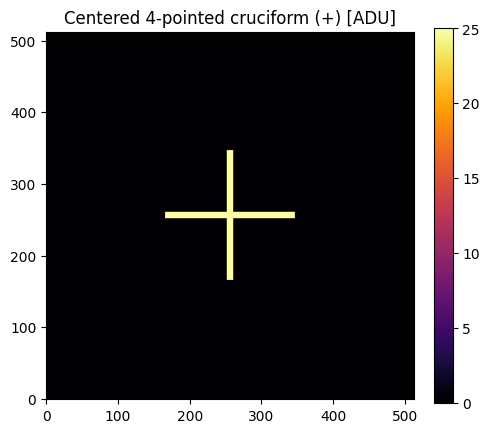

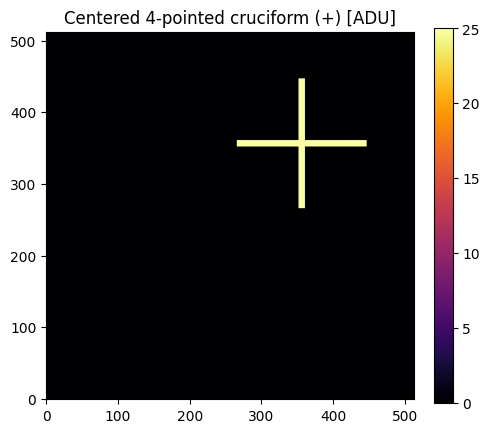

In [8]:
cruciform_centered = cruciform_shape(ny=ny, nx=nx, y0=y0, x0=x0)
cruciform_offcenter = cruciform_shape(ny=ny, nx=nx, y0=y0+100, x0=x0+100)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cruciform_centered, origin="lower", cmap="inferno")
ax.set_title("Centered 4-pointed cruciform (+) [ADU]")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cruciform_offcenter, origin="lower", cmap="inferno")
ax.set_title("Centered 4-pointed cruciform (+) [ADU]")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


In [9]:
# combine the readout with the stray light normalized to a certain level (level = fraction of net readout flux)

def combine_readout_and_stray_light(readout, stray_light, level):
    # return the net readout, and the stray light model

    # normalize the stray light to the net readout flux
    stray_light = (stray_light / np.sum(stray_light)) * np.sum(readout)

    # combine the readout and the stray light
    combined = readout + level * stray_light

    return combined, level * stray_light

In [10]:
net_readout_centered, stray_light_model_centered = combine_readout_and_stray_light(
                                                                        readout_adu, 
                                                                        cruciform_centered, 
                                                                        0.1)

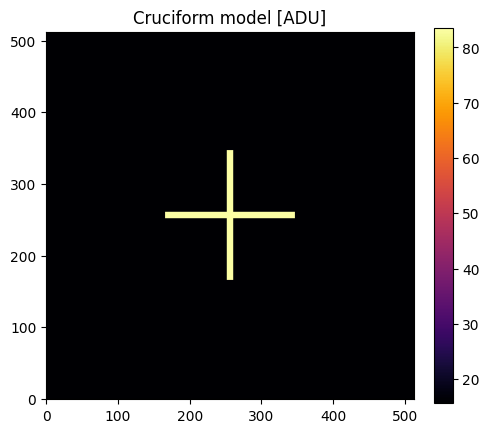

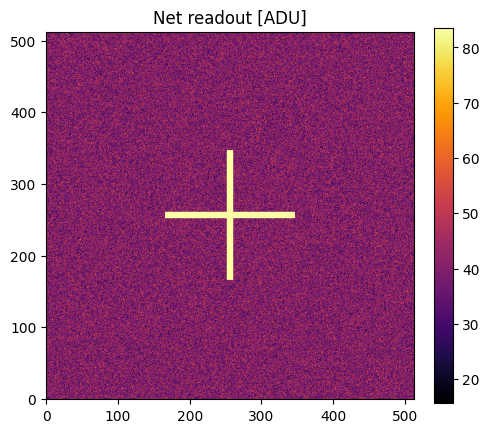

In [14]:

z_net = ZScaleInterval()
vmin_net, vmax_net = z_net.get_limits(net_readout_centered)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(stray_light_model_centered, origin="lower", cmap="inferno", vmin=vmin_net, vmax=vmax_net)
ax.set_title("Cruciform model [ADU]")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(net_readout_centered, origin="lower", cmap="inferno", vmin=vmin_net, vmax=vmax_net)
ax.set_title("Net readout [ADU]")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


In [ ]:
# Wiener deconvolution with normalized cruciform kernel

# cruciform kernel
kernel = cruciform_centered.astype(float)
kernel /= kernel.sum()

kernel_padded = np.zeros_like(net_readout_centered, dtype=float)
ky, kx = kernel.shape
cy, cx = net_readout_centered.shape[0] // 2, net_readout_centered.shape[1] // 2
y1, x1 = cy - ky // 2, cx - kx // 2
kernel_padded[y1 : y1 + ky, x1 : x1 + kx] = kernel

data_fft = np.fft.fft2(net_readout_centered)
kernel_fft = np.fft.fft2(kernel_padded)
reg = 0.01 * np.max(np.abs(kernel_fft) ** 2)
wiener_filter = np.conj(kernel_fft) / (np.abs(kernel_fft) ** 2 + reg)
data_deconvolved = np.real(np.fft.ifft2(data_fft * wiener_filter))

model = convolve2d(data_deconvolved, kernel, mode="same")
residuals = net_readout - model

z = ZScaleInterval()
vmin_r, vmax_r = z.get_limits(net_readout)
vmin_d, vmax_d = z.get_limits(data_deconvolved)
vmin_res, vmax_res = z.get_limits(residuals)
vlim_res = max(abs(vmin_res), abs(vmax_res))

fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

im0 = axs[0].imshow(net_readout, origin="lower", cmap="gray_r", vmin=vmin_r, vmax=vmax_r)
axs[0].set_title("Detector readout [ADU]")
fig.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(data_deconvolved, origin="lower", cmap="gray_r", vmin=vmin_d, vmax=vmax_d)
axs[1].set_title("Deconvolved data [ADU]")
fig.colorbar(im1, ax=axs[1], fraction=0.046)

im2 = axs[2].imshow(residuals, origin="lower", cmap="RdBu_r", vmin=-vlim_res, vmax=vlim_res)
axs[2].set_title("Residuals: readout − model [ADU]")
fig.colorbar(im2, ax=axs[2], fraction=0.046)

plt.show()


NameError: name 'convolve2d' is not defined

In [80]:
# convolve net_readout with a stray light model



convolved_data_cruciform_center = convolve(net_readout_centered, kernel=stray_light_model_centered, boundary='fill', fill_value=0.0)
#convolved_data_cruciform_offcenter = convolve(net_readout_centered, kernel=star_adu_offcenter, boundary='fill', fill_value=0.0)


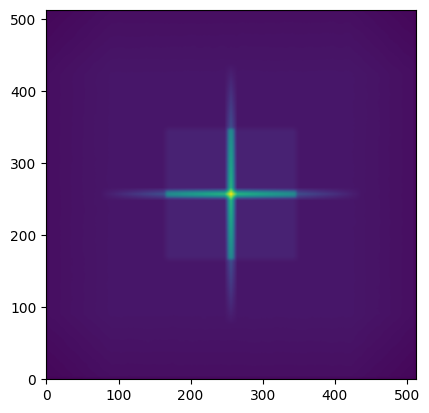

In [ ]:
plt.imshow(convolved_data_cruciform_center, origin="lower")
plt.show()

#plt.imshow(convolved_data_cruciform_offcenter, origin="lower")
#plt.show()

In [ ]:
# will need to generate a kernel for the stray light, possibly by taking frames at various angles relative to an off-center source

In [88]:
# subtract

deconvolved_data_centered = convolved_data_cruciform_center - net_readout_centered
#residuals_offcenter = data_deconvolved_offcenter - net_readout_offcenter

residuals_centered = net_readout_centered - deconvolved_data_centered

In [90]:
def plot_subplots(perfect_psf, stray_light_kernel, net_readout, convolved_data):
    data_minus_conv = net_readout - convolved_data
    residuals = net_readout - convolved_data

    z = ZScaleInterval()
    vmin_r, vmax_r = z.get_limits(net_readout)
    vmin_psf, vmax_psf = z.get_limits(perfect_psf)
    vmin_k, vmax_k = z.get_limits(stray_light_kernel)
    vmin_sub, vmax_sub = z.get_limits(data_minus_conv)
    vlim_res = max(abs(vmin_sub), abs(vmax_sub))

    fig, axs = plt.subplots(3, 2, figsize=(10, 12), constrained_layout=True)

    im00 = axs[0, 0].imshow(perfect_psf, origin="lower", cmap="inferno", vmin=vmin_psf, vmax=vmax_psf)
    axs[0, 0].set_title("Perfect PSF [ADU]")
    fig.colorbar(im00, ax=axs[0, 0], fraction=0.046)

    im01 = axs[0, 1].imshow(stray_light_kernel, origin="lower", cmap="inferno", vmin=vmin_k, vmax=vmax_k)
    axs[0, 1].set_title("Stray-light kernel [ADU]")
    fig.colorbar(im01, ax=axs[0, 1], fraction=0.046)

    im10 = axs[1, 0].imshow(net_readout, origin="lower", cmap="inferno", vmin=vmin_r, vmax=vmax_r)
    axs[1, 0].set_title("Net readout D [ADU]")
    fig.colorbar(im10, ax=axs[1, 0], fraction=0.046)

    im11 = axs[1, 1].imshow(convolved_data, origin="lower", cmap="inferno", vmin=vmin_r, vmax=vmax_r)
    axs[1, 1].set_title("D * K [ADU]")
    fig.colorbar(im11, ax=axs[1, 1], fraction=0.046)

    im20 = axs[2, 0].imshow(data_minus_conv, origin="lower", cmap="inferno", vmin=vmin_r, vmax=vmax_r)
    axs[2, 0].set_title("D − (D * K) [ADU]")
    fig.colorbar(im20, ax=axs[2, 0], fraction=0.046)

    im21 = axs[2, 1].imshow(residuals, origin="lower", cmap="RdBu_r", vmin=-vlim_res, vmax=vlim_res)
    axs[2, 1].set_title("Residuals: D − (D * K) [ADU]")
    fig.colorbar(im21, ax=axs[2, 1], fraction=0.046)

    plt.show()


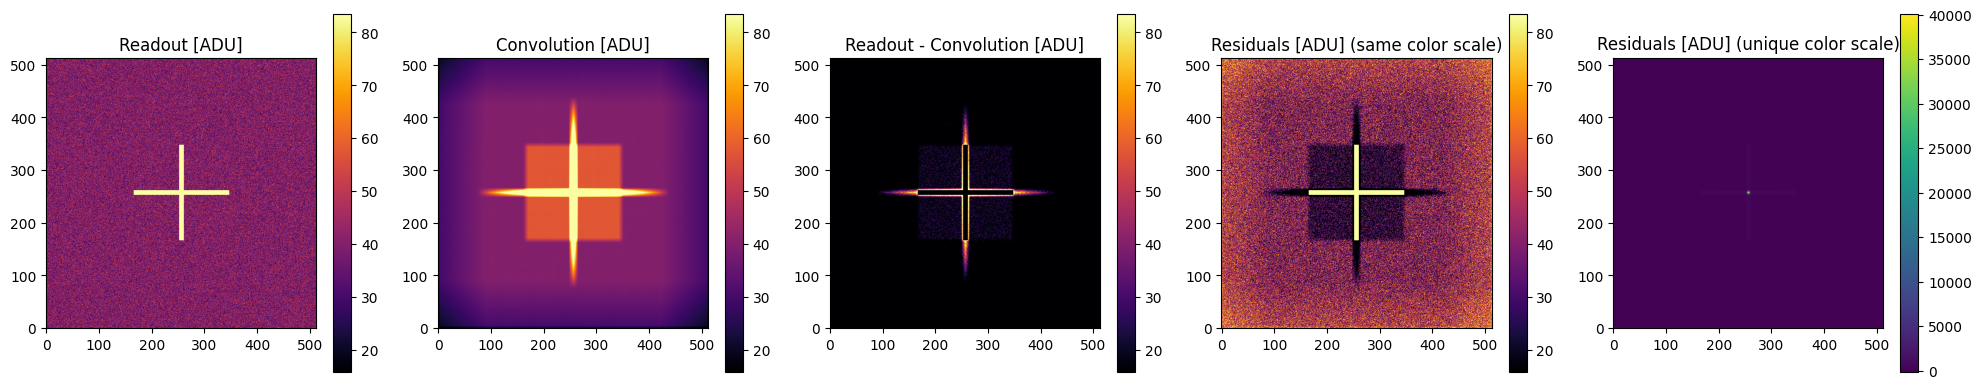

In [91]:
plot_subplots(
    perfect_psf=noise_free_adu,
    stray_light_kernel=stray_light_model_centered,
    net_readout=net_readout_centered,
    convolved_data=convolved_data_cruciform_center,
)
